In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

spambase = fetch_ucirepo(id=94)

X = spambase.data.features
y = spambase.data.targets

In [4]:
X.isna().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


In [5]:
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [6]:
X_original = X
y_original = y

In [7]:
y.head()

,Class
0,1
1,1
2,1
3,1
4,1


In [8]:
y.value_counts()

,count
Class,
0,2788
1,1813


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X_2D = pca.fit_transform(X)

In [10]:
# Proporcion de varianza explicada por cada componente
pca.explained_variance_ratio_

array([0.92702701, 0.07104297])

In [11]:
X_2D.shape

(4601, 2)

In [12]:
datos = np.hstack((X_2D, y))
datos.shape

(4601, 3)

In [13]:
datos = pd.DataFrame(datos, columns=['z1', 'z2', 'y'])
datos.sample(n=10)

,z1,z2,y
3184,-265.796933,6.730065,0.0
3685,-283.924769,-4.908357,0.0
1597,-98.467240,7.024575,1.0
1573,18.345766,87.554676,1.0
1801,-205.986274,6.633724,1.0
3172,-270.433192,-2.981018,0.0
558,703.630124,-22.078891,1.0
2043,234.792916,-73.805436,0.0
4126,-235.585637,-6.813463,0.0
3861,-81.695302,-26.262045,0.0


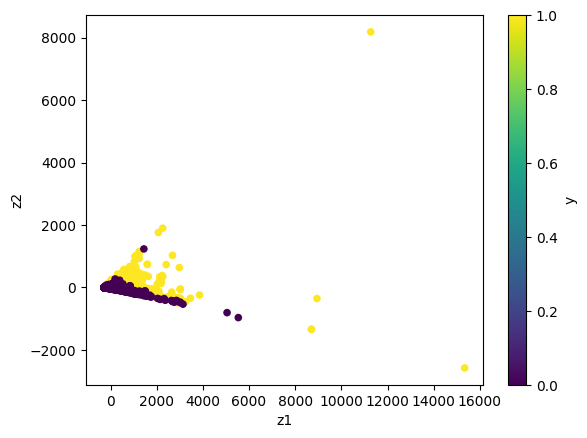

In [14]:
# Eje X = Primer componente principal
# Eye Y = Segundo componente principal
# c='y' Color segun la variable objetivo (0=no-spam, 1=spam)
#
# Si las clases spam/no-spam estan bien separadas, veremos grupos distintos
# Si estan mezcladas. sera mas dificil de clasificar
# Esta visualizacion nos ayuda a entender si PCA preserva la informacion de clasificacion
datos.plot.scatter(x='z1', y='z2', c='y')
plt.show()

In [15]:
# Eliminacion de outliers (valores atipicos)
from scipy import stats
# NOTA: En produccion, hay que ser cuidadosos con eliminar outliers, ya que podrian ser casos importantes
datos = datos[(np.abs(stats.zscore(datos)) < 3).all(axis=1)]

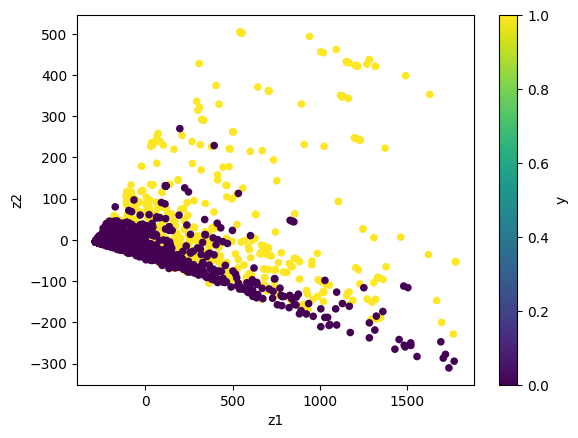

In [16]:
datos.plot.scatter(x='z1', y='z2', c='y')
plt.show()

In [17]:
y = datos[['y']]
y = np.ravel(y)

X = datos.drop('y', axis=1)

X.shape, y.shape

((4493, 2), (4493,))

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.15, random_state=42)
y_train, y_test = train_test_split(y, test_size=0.15, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3819, 2), (674, 2), (3819,), (674,))

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test) # En produccion solo usar .transform()

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

In [21]:
# ============================================================================
# BÚSQUEDA DE MEJORES HIPERPARÁMETROS CON GRIDSEARCH
# ============================================================================
# GridSearchCV prueba todas las combinaciones de parámetros para encontrar los mejores
#
# ESTRUCTURA DE LA RED NEURONAL:
# - Capa de entrada: 2 neuronas (una por cada componente principal: z1, z2)
# - Primera capa oculta: 5 o 10 neuronas (probaremos ambas)
# - Segunda capa oculta: 5 o 10 neuronas (probaremos ambas)
# - Capa de salida: 1 neurona (clasificación binaria: spam/no-spam)
#
# PARÁMETROS A OPTIMIZAR:
# - hidden_layer_sizes: Tamaño de las capas ocultas
#   - (5, 5): Dos capas ocultas con 5 neuronas cada una
#   - (10, 10): Dos capas ocultas con 10 neuronas cada una
# - learning_rate_init: Tasa de aprendizaje inicial (qué tan rápido aprende)
#   - 0.005: Aprendizaje más lento pero más estable
#   - 0.01: Aprendizaje más rápido pero puede ser menos estable
# - momentum: Momentum para el optimizador (ayuda a evitar mínimos locales)
#   - 0.5: Momentum moderado
#   - 0.9: Momentum alto (más inercia en el aprendizaje)
#
# n_jobs=-1: Usa todos los procesadores disponibles para acelerar la búsqueda
param_grid = [
    {'hidden_layer_sizes':[(5, 5), (10, 10)],
     'learning_rate_init':[0.005, 0.01],
     'momentum':[0.5, 0.9]
    }
]
modelo = GridSearchCV(MLPClassifier(), param_grid, n_jobs=-1)

# Entrenamos el modelo (GridSearchCV entrena múltiples modelos y elige el mejor)
modelo.fit(X_train_scaled, y_train)
print("Mejores parametros: {}".format(modelo.best_params_))

Mejores parametros: {'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.01, 'momentum': 0.5}


In [22]:
y_pred = modelo.predict(X_test_scaled)

In [23]:
# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
# confusion_matrix: Crea una tabla que muestra los aciertos y errores del modelo
from sklearn.metrics import confusion_matrix

# La matriz de confusión tiene 4 valores:
#                    Predicción
#                 No-Spam  Spam
# Real  No-Spam    [TN]   [FP]  ← Verdaderos Negativos y Falsos Positivos
#       Spam       [FN]   [TP]  ← Falsos Negativos y Verdaderos Positivos
#
# - TN (True Negative): Correctamente predijo no-spam
# - FP (False Positive): Incorrectamente predijo spam (error tipo I)
# - FN (False Negative): Incorrectamente predijo no-spam (error tipo II)
# - TP (True Positive): Correctamente predijo spam
#
# Esta matriz nos ayuda a entender qué tipos de errores comete el modelo
cm = confusion_matrix(y_test, y_pred)

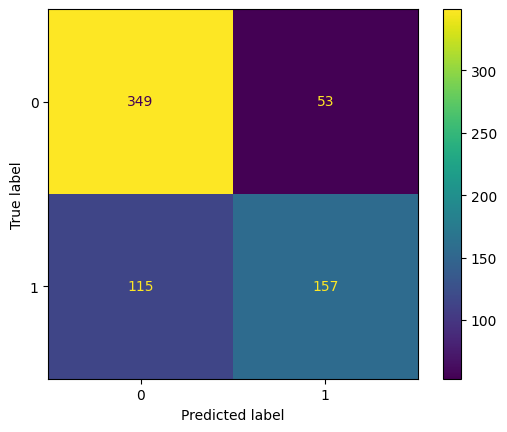

In [25]:
# VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
# ConfusionMatrixDisplay: Crea una visualización gráfica de la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

# Esto nos permite ver visualmente:
# - Cuántas predicciones fueron correctas (diagonal principal)
# - Qué tipos de errores comete el modelo
# - Si hay algún sesgo hacia una clase u otra
#
# Un buen modelo tendrá la mayoría de valores en la diagonal (predicciones correctas)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

In [26]:
# CÁLCULO DE PRECISIÓN (ACCURACY)
# accuracy_score: Calcula el porcentaje de predicciones correctas
from sklearn.metrics import accuracy_score

# Fórmula: (TP + TN) / (TP + TN + FP + FN)
#          Total de predicciones correctas / Total de predicciones
#
# Un accuracy de 0.85 significa que el 85% de las predicciones fueron correctas
#
# NOTA: Accuracy puede ser engañoso si hay desbalance de clases
#          En esos casos, es mejor usar otras métricas como F1-score o ROC-AUC
round(accuracy_score(y_test, y_pred), 2)

0.75


# COMPARACIÓN: USANDO 5 COMPONENTES PRINCIPALES
# ============================================================================
# Ahora vamos a probar con 5 componentes en lugar de 2
#
# ¿Por qué 5 componentes?
# - Con 2 componentes podemos visualizar, pero podríamos perder información
# - Con 5 componentes capturamos más varianza de los datos originales
# - Es un balance entre reducción de dimensionalidad y preservación de información
#
# Esperamos que:
# - El modelo tenga mejor rendimiento (más información = mejor clasificación)
# - Pero el entrenamiento sea un poco más lento (más características)
#
# Vamos a comparar los resultados con los obtenidos usando 2 componentes

Mejores parametros: {'hidden_layer_sizes': (10, 10), 'learning_rate_init': 0.01, 'momentum': 0.5}


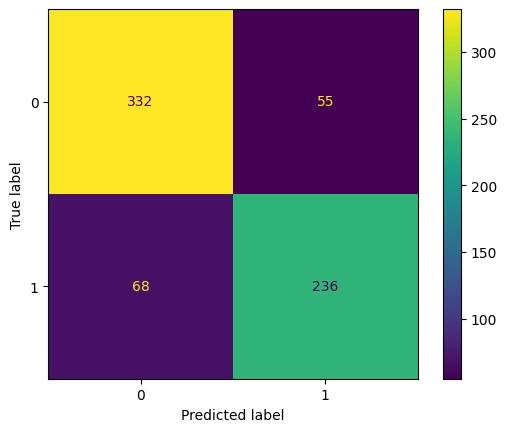

0.82

In [27]:
# PCA CON 5 COMPONENTES PRINCIPALES
# Aplicamos PCA nuevamente, pero esta vez conservando 5 componentes
# Esto captura más información que con 2 componentes
pca = PCA(n_components = 5)
X_5d = pca.fit_transform(X_original)  # Reducimos de 57 a 5 dimensiones
y = np.ravel(y_original)

# División en entrenamiento y prueba (mismo proceso que antes)
X_train, X_test = train_test_split(X_5d, test_size=0.15, random_state=42)
y_train, y_test = train_test_split(y, test_size=0.15, random_state=42)

# Normalización de datos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Mismo grid de parámetros para comparar resultados
param_grid = [
    {'hidden_layer_sizes':[(5, 5), (10, 10)],
     'learning_rate_init':[0.005, 0.01],
     'momentum':[0.5, 0.9]
    }
]

# max_iter=500: Aumentamos el número máximo de iteraciones
#               Con más características, el modelo puede necesitar más iteraciones para converger
modelo = GridSearchCV(MLPClassifier(max_iter=500), param_grid, n_jobs=-1)
modelo.fit(X_train_scaled, y_train)
print("Mejores parametros: {}".format(modelo.best_params_))

# Predicciones y evaluación
y_pred = modelo.predict(X_test_scaled)

# Matriz de confusión y visualización
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

# Accuracy final
round(accuracy_score(y_test, y_pred), 2)

# ============================================================================
# COMPARACIÓN DE RESULTADOS
# ============================================================================
# Compara el accuracy obtenido con 5 componentes vs el obtenido con 2 componentes
#
# Preguntas para reflexionar:
# - ¿Mejoró el rendimiento con 5 componentes?
# - ¿Vale la pena el costo computacional adicional?
# - ¿Cuánta varianza capturan los 5 componentes? (puedes verificar con pca.explained_variance_ratio_)